In [1]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) =  keras.datasets.cifar10.load_data()

In [3]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [29]:
y_train = y_train.reshape(-1,)

Display Image

In [4]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "house",
           "ship", "truck"]

In [30]:
def number(index):
    print(index)
    plt.figure(figsize=(15,2))
    plt.imshow(X_train[index])
    print("---" * 15)
    print(f"The image is {classes[y_train[index]]}")
    print("---" * 15)

33526
---------------------------------------------
The image is cat
---------------------------------------------


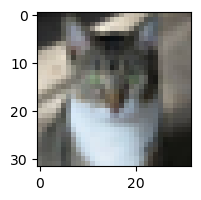

In [33]:
import random
index = random.randrange(0, 50000)
number(index)

In [34]:
import numpy as np
from sklearn.model_selection import train_test_split

def split_images(images, labels, val_size=0.2, random_state=None):
    # Convert the image filenames and labels to numpy arrays
    images = np.array(images)
    labels = np.array(labels)

    # Split the images and labels into training and validation sets
    train_images, val_images, train_labels, val_labels = train_test_split(
        images, labels, test_size=val_size, random_state=random_state)

    return train_images, val_images, train_labels, val_labels


In [35]:
X_train, X_val, y_train, y_val = split_images(X_train, y_train, 0.1, random_state=51)

In [36]:
X_train.shape, X_val.shape

((45000, 32, 32, 3), (5000, 32, 32, 3))

Converting labels into a 1D array

In [46]:
# y_train = y_train.reshape(-1,)

In [37]:
y_val = y_val.reshape(-1,)

In [38]:
y_test = y_test.reshape(-1,)

Normalization

In [39]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

In [40]:
X_train[0].shape

(32, 32, 3)

ANN

In [13]:
model = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation="relu"),
    layers.Dense(1000, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [14]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [15]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))

Epoch 1/5
1407/1407 [==============================] - 108s 76ms/step - loss: 2.1003 - accuracy: 0.3019 - val_loss: 1.8612 - val_accuracy: 0.3336
Epoch 2/5
1407/1407 [==============================] - 108s 76ms/step - loss: 1.7229 - accuracy: 0.3883 - val_loss: 1.7048 - val_accuracy: 0.3930
Epoch 3/5
1407/1407 [==============================] - 112s 79ms/step - loss: 1.6529 - accuracy: 0.4135 - val_loss: 1.8295 - val_accuracy: 0.3622
Epoch 4/5
1407/1407 [==============================] - 117s 83ms/step - loss: 1.6167 - accuracy: 0.4285 - val_loss: 1.9855 - val_accuracy: 0.3368
Epoch 5/5
1407/1407 [==============================] - 116s 83ms/step - loss: 1.5947 - accuracy: 0.4368 - val_loss: 1.8830 - val_accuracy: 0.3568


In [16]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 3s 11ms/step - loss: 1.8876 - accuracy: 0.3545


[1.8876322507858276, 0.3544999957084656]

CNN

In [41]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3), padding="same"),
    layers.Dropout(0.2),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Dropout(0.5),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [42]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [43]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
1407/1407 [==============================] - 47s 33ms/step - loss: 1.4687 - accuracy: 0.4784 - val_loss: 1.3200 - val_accuracy: 0.5514
Epoch 2/10
1407/1407 [==============================] - 51s 36ms/step - loss: 1.1226 - accuracy: 0.6073 - val_loss: 1.1543 - val_accuracy: 0.6138
Epoch 3/10
1407/1407 [==============================] - 70s 50ms/step - loss: 0.9985 - accuracy: 0.6530 - val_loss: 1.1098 - val_accuracy: 0.6268
Epoch 4/10
1136/1407 [=======================>......] - ETA: 15s - loss: 0.9261 - accuracy: 0.6783

In [60]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 5ms/step - loss: 1.1568 - accuracy: 0.6547


[1.1567816734313965, 0.654699981212616]